# Financial Database Analysis Report

## Executive Summary

This report analyzes the fintech platform database across four areas: account balances, transaction behavior, geographic balance distribution, and exchange-rate integrity. The results highlight core activity patterns and key operational risks.

## Database Overview

The analysis uses a PostgreSQL database with four main tables: Users, Accounts, Transactions, and ExchangeRates. Users and Accounts provide customer and balance context, Transactions captures money movement, and ExchangeRates supports multi-currency conversion.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sqlalchemy import create_engine

In [2]:
engine = create_engine("postgresql+psycopg2://philiploewen:@localhost:5432/Fintech")

In [3]:
get_accounts_data_query = """
    SELECT *
    FROM Records.Accounts
    """

df = pd.read_sql(get_accounts_data_query, engine)

df.head()

,account_id,user_id,account_number,currency_code,balance,pending_balance,account_status,created_at,updated_at
0,7b4071b5-4221-494f-8e91-e760be4b8388,5e0f860f-475f-47ae-bb29-6cb6510adf66,689306535663,EUR,3699.0052,0.0,Active,2026-03-16 16:49:34.814453,2026-03-16 16:49:34.814453
1,4543b96c-8a2a-492e-9c80-97299488e0c1,52c8f9e9-a790-4f71-b835-31ecc34b78d0,709549040802,EUR,3081.0314,0.0,Active,2026-03-16 16:49:34.814453,2026-03-16 16:49:34.814453
2,daac8a42-adc1-40c1-8147-bdf1cea9d6b1,2db84024-a80f-423e-af4c-e0d0c1366a3a,497665460087,EUR,1325.2922,0.0,Active,2026-03-16 16:49:34.814453,2026-03-16 16:49:34.814453
3,50bdbf18-ea5b-4235-94e9-2778f505e2e1,9228f0c9-610c-4c70-82ed-b861dae61cfd,706188279582,USD,276.5973,0.0,Active,2026-03-16 16:49:34.814453,2026-03-16 16:49:34.814453
4,19cd71d7-7aba-44b0-a07d-2e43a29a528d,8952993c-bf6d-46a0-a915-381482d8407e,994160034694,EUR,419.9252,0.0,Active,2026-03-16 16:49:34.814453,2026-03-16 16:49:34.814453


In [4]:
get_users_data_query = """
    SELECT *
    FROM Records.Users
    """

df = pd.read_sql(get_users_data_query, engine)

df.head()


,user_id,email_address,first_name,last_name,kyc_status,country_code,created_at,is_active
0,614dd9d5-0ccc-41f4-9b5a-bc631b61b7b3,simonedarc0@outlookcom,Simone,d'Arc,Pending,FR,2026-03-16 16:49:34.814453,True
1,44fcd4bc-3e97-4756-9ee8-0e94f67b14da,elizabethnightingale1@icloudcom,Elizabeth,Nightingale,Pending,DE,2026-03-16 16:49:34.814453,True
2,7e0e642b-54c9-4432-9589-2e06c67a4a79,catherinebernoulli2@yahoocom,Catherine,Bernoulli,Pending,CA,2026-03-16 16:49:34.814453,True
3,aab402a6-fe89-49ec-a45d-c10afb9ba3b9,rosashelly3@gmailcom,Rosa,Shelly,Pending,FR,2026-03-16 16:49:34.814453,True
4,977379e3-9be4-443f-8745-dc1ca72fcceb,mariethatcher4@gmailcom,Marie,Thatcher,Pending,CA,2026-03-16 16:49:34.814453,True


In [5]:
get_transactions_data_query = """
    SELECT *
    FROM Records.Transactions
    """

df = pd.read_sql(get_transactions_data_query, engine)

df.head()


,transaction_id,sender_account_id,receiver_account_id,base_amount,source_currency,target_currency,exchange_rate,created_at
0,00ef36c8-e57a-49b1-b023-97cb3db1c411,268a10a8-76dd-4cf2-b9d2-63fec357178e,19cd71d7-7aba-44b0-a07d-2e43a29a528d,167.0867,USD,EUR,0.8691,2026-03-16 17:10:44.668329
1,d818713e-7d63-476a-8cac-a5022868bec4,0896e51c-032e-4089-98be-34d263d8f65e,6e331558-3a07-4239-903f-b00b67fb7cb1,240.7400,EUR,EUR,1.0000,2026-03-16 17:10:44.677404
2,055d6f8c-1672-40ba-8c8e-f2461b90aa8f,42db4df4-08f4-460c-9b0d-a4939b26bc18,a5f7bf6a-4cb5-4beb-a429-05d8fb3f8946,168.4105,CAD,CAD,1.0000,2026-03-16 17:10:44.679863
3,871622cb-d067-45b9-924e-75f6232ca2e4,65995629-5063-4e91-8482-69d70bb6448b,892bdd5c-da9d-413b-a025-630ea3678bfe,389.4168,CAD,USD,0.7308,2026-03-16 17:10:44.682296
4,df7199c9-0fee-4c1f-9950-f3be3f1f6dcd,9adbeb81-ed0f-46b2-a182-9224332fbe80,19cab54a-0e8f-4920-b31e-136c20308ebd,237.6232,CAD,EUR,0.6352,2026-03-16 17:10:44.684772


## Analysis 1: High-Value Customer Identification

### Methodology

This analysis identifies the accounts with the highest balances. The metric helps quantify wealth concentration and flag high-value customers for risk and relationship management.

### Top Accounts by Balance

The query below returns the 10 accounts with the largest balances, ordered from highest to lowest.

In [6]:
highest_balance_query = """
    WITH er AS (
        SELECT source_currency, target_currency, exchange_rate
        FROM Records.ExchangeRates
        WHERE target_currency = 'USD'
        UNION ALL
        SELECT 'USD', 'USD', 1::numeric(9)
    )
    SELECT a.balance * er.exchange_rate as balance_usd, a.user_id 
    FROM Records.Accounts as a
    INNER JOIN er
    ON a.currency_code = er.source_currency
    ORDER BY balance_usd DESC
    """

df = pd.read_sql(highest_balance_query, engine)

df.head(10)

,balance_usd,user_id
0,17776.090067,ebb22b78-e39f-4b16-8e61-677d40619704
1,16692.988877,92602d99-5e6a-4bc0-ac54-759ee4c196ac
2,13696.401523,56e453c2-f8ca-47fb-8648-5ac855065af6
3,11639.674804,39c010f0-6400-4b43-aebf-4bc454b379d7
4,11239.314187,809db9f5-aeda-41bf-b095-4b0e710135fa
5,9528.395327,911ad8a7-2fa1-4142-ba14-ca5ef7f5cf7d
6,8904.359980,977379e3-9be4-443f-8745-dc1ca72fcceb
7,4986.637726,ee8d5cc2-fa84-473e-b3a3-8d2f991fb7cc
8,4245.718169,5e0f860f-475f-47ae-bb29-6cb6510adf66
9,3680.249104,7dcbaea6-7d28-4563-866c-5c5038790c76


### User-Level Analysis

To make the ranking actionable, we join Accounts to Users and attach each high-balance account to a named user. This enables direct customer-level interpretation rather than account-level output alone.

In [7]:
users_highest_balance_query = """
    WITH er AS (
        SELECT source_currency, target_currency, exchange_rate
        FROM Records.ExchangeRates
        WHERE target_currency = 'USD'
        UNION ALL
        SELECT 'USD', 'USD', 1::numeric(9)
    )
    SELECT u.first_name, u.last_name, a.balance * er.exchange_rate as balance_USD
    FROM Records.Accounts as a
    INNER JOIN Records.Users as u
    ON a.user_id = u.user_id
    INNER JOIN er
    ON a.currency_code = er.source_currency
    ORDER BY balance_usd DESC
    """

df_user_balance = pd.read_sql(users_highest_balance_query, engine)

df_user_balance.head(10)


,first_name,last_name,balance_usd
0,Bernhard,Bernoulli,17776.090067
1,Catherine,Markov,16692.988877
2,Marie,Galois,13696.401523
3,Marie,Thatcher,11639.674804
4,Simone,Markov,11239.314187
5,Jeanne,Bernoulli,9528.395327
6,Marie,Thatcher,8904.359980
7,Karl,Galois,4986.637726
8,Catherine,Antoinette,4245.718169
9,Rosa,Riemann,3680.249104


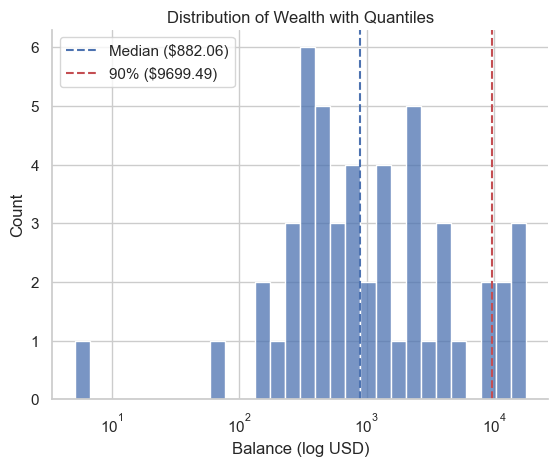

In [8]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="whitegrid", rc=custom_params)
sns.histplot(df_user_balance["balance_usd"], bins = 30, log_scale=True)

quantiles = np.quantile(df_user_balance["balance_usd"], [0.5, 0.90])
labels = ["Median", "90%"]
colors = ['b', 'r']

for q, label, c in zip(quantiles, labels, colors):
    plt.axvline(q, color = f'{c}', linestyle = '--', label = f'{label} (${q:.2f})')

plt.title("Distribution of Wealth with Quantiles")
plt.xlabel("Balance (log USD)")
plt.legend()
plt.show()

We can see that the distribution follows a rough bell shape on a log axis. This reflects the initialization process of the database which used a lognormal distribution to generate individual wealth. 

## Analysis 2: Geographic Distribution of Wealth

### Methodology

This section compares average account balances by country. We aggregate balances at the country level and rank countries by mean balance to highlight regional differences in user wealth.

### Average Balance by Country

The query computes average balance for each country and sorts results in descending order.

In [9]:
country_highest_balance_query = """
WITH u AS (
    SELECT user_id, country_code
    FROM Records.Users
),
er AS (
        SELECT source_currency, target_currency, exchange_rate
        FROM Records.ExchangeRates
        WHERE target_currency = 'USD'
        UNION ALL
        SELECT 'USD', 'USD', 1::numeric(9)
    )
SELECT u.country_code, 
       AVG(a.balance*exchange_rate) as avg_balance_usd,
       PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY a.balance * exchange_rate) as median_balance_usd
FROM Records.Accounts as a
INNER JOIN u
ON a.user_id = u.user_id
INNER JOIN er
ON a.currency_code = er.source_currency
GROUP BY u.country_code 
ORDER BY avg_balance_usd DESC
"""

country_balance_df = pd.read_sql(country_highest_balance_query, engine)

country_balance_df

,country_code,avg_balance_usd,median_balance_usd
0,CA,9683.228724,10383.854757
1,DE,1494.861785,1142.349098
2,FR,964.698459,453.209002
3,US,682.512880,631.126700


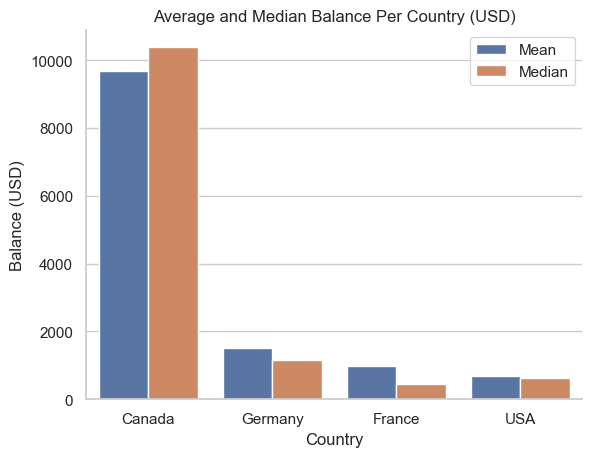

In [10]:
country_balance_melted = country_balance_df.melt(
    id_vars="country_code",
    value_vars=["avg_balance_usd", "median_balance_usd"],
    var_name="metric",
    value_name="balance",
)

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="whitegrid", rc=custom_params)

h = sns.barplot(
    data=country_balance_melted, x="country_code", y="balance", hue="metric"
)

h.set_xticks([0, 1, 2, 3])
h.set_xticklabels(["Canada", "Germany", "France", "USA"])
plt.title("Average and Median Balance Per Country (USD)")
plt.xlabel("Country")
plt.ylabel("Balance (USD)")
plt.legend(handles=h.legend_.legend_handles, labels=["Mean", "Median"])
plt.show()


Canada shows substantially higher average and median balances than Germany, France, and the USA, indicating a wealthier user base. Germany and France show mean-to-median divergence, suggesting right-skewed distributions with high-balance outliers. The USA displays greater symmetry between the two metrics.

This concentration suggests region-specific demand variations that warrant investigation and may support differentiated pricing or product strategies by geography.

## Analysis 3: Transaction Activity Analysis

### Methodology

This analysis ranks user activity using two metrics: number of transfers sent and total value sent. Together, they show participation intensity and transaction throughput.

### Data Integration Considerations

Transactions references accounts through sender_account_id, so user-level activity requires joins through Accounts. The workflow is:
1. Join Accounts to Users to map account IDs to user identities
2. Join aggregated transaction statistics back to Accounts

Note: The current schema assigns one account per user. The query pattern still supports future multi-account users by aggregating before final user mapping.

### Top Transaction Senders

The query below returns the 10 users with the most sent transactions, along with total amount sent.

In [11]:
users_most_sent_query = """
    WITH u AS (
        SELECT user_id, first_name, last_name
        FROM Records.Users
    ),
    t AS (
        SELECT sender_account_id, SUM(1) as transfers_sent, SUM(base_amount) as amount_sent
        FROM Records.Transactions
        GROUP BY sender_account_id
    )
    SELECT u.first_name, u.last_name, t.transfers_sent, t.amount_sent, a.user_id, a.account_id 
    FROM Records.Accounts as a
    INNER JOIN u
    ON a.user_id = u.user_id
    INNER JOIN t
    ON a.account_id = t.sender_account_id
    ORDER BY t.transfers_sent DESC
    LIMIT 10
    """

df = pd.read_sql(users_most_sent_query, engine)

df

,first_name,last_name,transfers_sent,amount_sent,user_id,account_id
0,Marie,Thatcher,983,391887.8526,977379e3-9be4-443f-8745-dc1ca72fcceb,63e35475-1b32-408b-b3f4-604fdabd93c1
1,Andrei,Thatcher,971,389941.4685,7181f279-28c4-4e8e-8eff-89e0cd2bbf55,a5f7bf6a-4cb5-4beb-a429-05d8fb3f8946
2,Simone,Markov,969,393101.7873,809db9f5-aeda-41bf-b095-4b0e710135fa,5d87f00e-ec60-4ac5-a66f-735fe0492fe0
3,Karl,Galois,966,392343.6122,ee8d5cc2-fa84-473e-b3a3-8d2f991fb7cc,4b06961d-a643-4865-82a0-0db75b6240a4
4,Marie,Thatcher,966,375730.9552,39c010f0-6400-4b43-aebf-4bc454b379d7,d1ac9187-6246-483a-9287-68538b7a4891
5,Catherine,Bernoulli,965,387833.2277,7e0e642b-54c9-4432-9589-2e06c67a4a79,b342ca35-d30e-4247-a5b9-3b5e957028c4
6,Bernhard,Bernoulli,964,399346.8920,ebb22b78-e39f-4b16-8e61-677d40619704,65995629-5063-4e91-8482-69d70bb6448b
7,Catherine,Markov,956,395998.2757,92602d99-5e6a-4bc0-ac54-759ee4c196ac,42db4df4-08f4-460c-9b0d-a4939b26bc18
8,Marie,Galois,948,355110.9206,56e453c2-f8ca-47fb-8648-5ac855065af6,7c2038a8-1fd5-463c-a340-ba1e72265562
9,Jeanne,Bernoulli,913,351794.6795,911ad8a7-2fa1-4142-ba14-ca5ef7f5cf7d,9adbeb81-ed0f-46b2-a182-9224332fbe80


### Technical Note on Multi-Account Scenarios

The current schema assigns one account per user. In production, multi-account support should include a final user-level aggregation so activity is summed across all accounts owned by the same user.

### Network Analysis: Platform Hubs

This section identifies users who act as transaction hubs. We define hub behavior with two criteria:
1. **High transaction volume** - high count of initiated transfers
2. **Wide receiver network** - high count of distinct recipient accounts

Users high on both measures are structurally important to network flow and concentration risk.

The query below counts unique recipients per sender to measure reach alongside transaction value.

In [12]:
users_most_unique_query = """
    WITH u AS (
        SELECT user_id, first_name, last_name
        FROM Records.Users
    ),
    t AS (
        SELECT COUNT(DISTINCT receiver_account_id) as unique_sent, SUM(base_amount) as amount_sent, 
               sender_account_id
        FROM Records.Transactions
        GROUP BY sender_account_id
    )
    SELECT u.first_name, u.last_name, t.unique_sent, t.amount_sent, a.user_id, a.account_id 
    FROM Records.Accounts as a
    INNER JOIN u
    ON a.user_id = u.user_id
    INNER JOIN t
    ON a.account_id = t.sender_account_id
    ORDER BY t.unique_sent DESC
    """

df = pd.read_sql(users_most_unique_query, engine)

df.head()


,first_name,last_name,unique_sent,amount_sent,user_id,account_id
0,Jacob,Lebesgue,49,258805.6955,cd81dce1-ac29-424b-9691-1768f22834e7,00ac2f87-a784-422a-8c66-7ed21fdd4b73
1,Augustin,Riemann,49,243519.4560,ef13f4e2-96be-473e-adc5-6fcafb1f640b,0896e51c-032e-4089-98be-34d263d8f65e
2,Florence,Kalo,49,260218.2398,4eae5787-70ca-4578-8acd-486ae73298ad,0aaf8c06-7c14-491a-8bc3-f72586ec6d0c
3,Simone,Nightingale,49,245469.9240,4c9439c6-1c01-40a0-8b58-94a540363d8d,0fe7fb90-65ec-49e0-9987-c9d3aef3f236
4,Rosa,Riemann,49,252430.9132,7dcbaea6-7d28-4563-866c-5c5038790c76,19cab54a-0e8f-4920-b31e-136c20308ebd


### Findings

In this test dataset, every user has transferred to every other user. That indicates full connectivity in test data, but it is unlikely in production, where transaction graphs usually show clustering and selective links.

### Comprehensive Activity Analysis: Total Transaction Volume

Previous sections looked at outbound volume or recipient breadth separately. Here we use **total transaction participation** to combine inbound and outbound activity into one metric.

#### Methodology and Significance

High total-activity users often act as:
- **Liquidity Providers**: active on both sending and receiving sides
- **Economic Validators**: contributors to transaction volume and pricing signal quality
- **Network Stabilizers**: high-frequency participants that increase connectivity

By combining transfers initiated and transfers received, we identify the primary transaction nodes regardless of direction.

#### Query Design

The analysis aggregates sender and receiver activity separately, then joins both streams at the account level to map totals to users.

#### Results

In [13]:
users_most_transfers_query = """
    WITH u AS (
        SELECT user_id, first_name, last_name
        FROM Records.Users
    ),
    sender AS (
        SELECT sender_account_id, SUM(1) as transfers_sent
        FROM Records.Transactions
        GROUP BY sender_account_id
    ),
    receiver AS (
        SELECT receiver_account_id, SUM(1) as transfers_received
        FROM Records.Transactions
        GROUP BY receiver_account_id
    )
    SELECT u.first_name, u.last_name, 
           sender.transfers_sent + receiver.transfers_received as total_transfers, 
           a.user_id, a.account_id 
    FROM Records.Accounts as a
    INNER JOIN u
    ON a.user_id = u.user_id
    INNER JOIN sender
    ON a.account_id = sender.sender_account_id
    INNER JOIN receiver
    ON receiver.receiver_account_id = sender.sender_account_id
    ORDER BY total_transfers DESC
    """

user_transfers_df = pd.read_sql(users_most_transfers_query, engine)

user_transfers_df.head()

,first_name,last_name,total_transfers,user_id,account_id
0,Marie,Thatcher,1834,977379e3-9be4-443f-8745-dc1ca72fcceb,63e35475-1b32-408b-b3f4-604fdabd93c1
1,Karl,Galois,1817,ee8d5cc2-fa84-473e-b3a3-8d2f991fb7cc,4b06961d-a643-4865-82a0-0db75b6240a4
2,Bernhard,Bernoulli,1810,ebb22b78-e39f-4b16-8e61-677d40619704,65995629-5063-4e91-8482-69d70bb6448b
3,Catherine,Markov,1807,92602d99-5e6a-4bc0-ac54-759ee4c196ac,42db4df4-08f4-460c-9b0d-a4939b26bc18
4,Simone,Markov,1796,809db9f5-aeda-41bf-b095-4b0e710135fa,5d87f00e-ec60-4ac5-a66f-735fe0492fe0


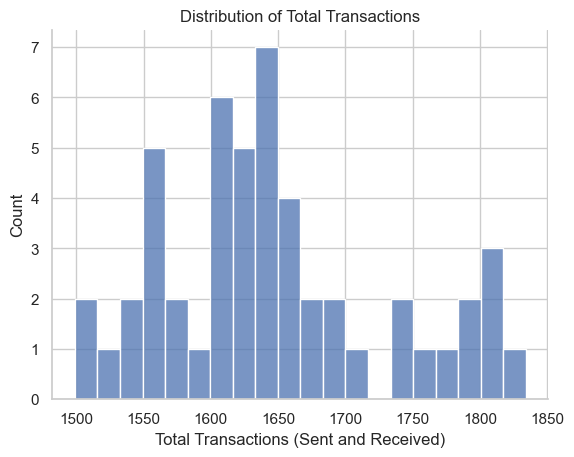

In [14]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="whitegrid", rc = custom_params)
sns.histplot(user_transfers_df["total_transfers"], bins = 20)

plt.title("Distribution of Total Transactions")
plt.xlabel("Total Transactions (Sent and Received)")
plt.show()

### Analysis of Total Transaction Volume

The results above list the 10 most active users by total transaction participation (sent + received transfers).

#### Key Insights

**User Importance Ranking**: Total transaction volume provides a single measure of contribution to platform throughput. It is useful for:

- **Customer Retention Strategy**: prioritizing engagement for consistently high-activity users
- **Revenue Optimization**: identifying users and segments that generate the most fee-bearing activity
- **Platform Stability**: tracking dependency on a small set of core participants
- **Benchmarking User Value**: using transaction count as a practical proxy for platform contribution

#### Comparative Analysis

Compared with earlier views:
- Users with high balances may not be highly active (wealth concentration vs. activity)
- Users with many unique recipients may still have fewer total transfers (breadth vs. intensity)
- Total transfer activity gives a direct ranking of overall participation

This metric is a useful leading indicator of platform health and engagement trends.

### Cross-Border Transaction Analysis: International Transfer Leaders

This section focuses only on international transactions (sender and receiver in different countries). Cross-border flows matter because they carry distinct compliance requirements and revenue characteristics.

#### Methodology and Business Context

Cross-border activity is important for four reasons:

1. **Regulatory Complexity**: stronger AML and cross-jurisdiction compliance requirements
2. **Economic Value**: higher fee potential from conversion and international transfer services
3. **Market Expansion Signal**: evidence of adoption beyond domestic corridors
4. **Platform Differentiation**: strength in international payments is a competitive advantage

We filter to cross-country transfers, then identify users with the highest international transaction activity.

#### Query Architecture

The query:

1. Enriches each transaction with sender and receiver country data
2. Filters out domestic transfers
3. Aggregates sent and received international transfers separately
4. Reconciles account-level activity back to user identities

This yields users who act as international transfer nodes in the platform.

In [15]:
users_most_foreign_transfers_query = """
    WITH ft AS (
        SELECT t.*, c.first_name as sender_first_name, c.last_name as sender_last_name, 
            c.country_code as sender_country, 
            d.first_name as receiver_first_name, d.last_name as receiver_last_name, 
            d.country_code as receiver_country
        FROM Records.Transactions as t
        INNER JOIN Records.Accounts as a
        ON t.sender_account_id = a.account_id
        INNER JOIN Records.Accounts as b
        ON t.receiver_account_id = b.account_id
        INNER JOIN Records.Users as c
        ON a.user_id = c.user_id
        INNER JOIN Records.Users as d
        ON b.user_id = d.user_id
        WHERE NOT c.country_code = d.country_code
    ),
    sender AS (
        SELECT SUM(1) as transfers_sent, sender_account_id
        FROM ft
        GROUP BY sender_account_id
    ),
    receiver AS (
        SELECT SUM(1) as transfers_received, receiver_account_id
        FROM ft
        GROUP BY receiver_account_id
    )
    SELECT u.first_name, u.last_name, 
           s.transfers_sent + r.transfers_received as total_foreign_transfers
    FROM Records.Accounts as a
    INNER JOIN Records.Users as u
    ON a.user_id = u.user_id
    INNER JOIN sender as s
    ON a.account_id = s.sender_account_id
    INNER JOIN receiver as r
    ON a.account_id = r.receiver_account_id
    ORDER BY total_foreign_transfers DESC
    LIMIT 10
    """

df = pd.read_sql(users_most_foreign_transfers_query, engine)

df


,first_name,last_name,total_foreign_transfers
0,Catherine,Markov,1458
1,Marie,Thatcher,1457
2,Bernhard,Bernoulli,1457
3,Karl,Galois,1425
4,Jeanne,de Beauvoir,1414
5,Simone,Markov,1412
6,Catherine,Bernoulli,1401
7,Marie,Thatcher,1399
8,Andrei,Thatcher,1391
9,Marie,Galois,1391


#### Findings on International Activity

The results identify the 10 users with the highest cross-border transfer volume. These users are central to the platform's international footprint.

**Strategic Implications**:

- **Revenue Generation**: high cross-border users are likely strong fee contributors
- **Market Validation**: their activity confirms demand for international payment capabilities
- **Geographic Exposure**: their origin countries indicate where expansion is gaining traction
- **Risk Concentration**: reliance on a small group of users creates churn sensitivity

**Comparative Context**:

Cross-border and total transaction rankings can diverge because users may:
- transact mostly domestically with occasional international transfers
- use international rails for specific use cases (for example remittances or business payments)
- belong to segments with distinct international behavior

Track this segment against total platform growth to ensure international adoption is keeping pace.

## Analysis 4: Exchange Rate Integrity Assessment

### Methodology

Multi-currency platforms are exposed to triangular arbitrage risk. Arbitrage exists when a sequence of conversions returns more than the starting amount. Example: if USD -> CAD -> EUR -> USD yields more than 1 USD, rates violate no-arbitrage consistency.

This analysis tests all three-currency paths in the exchange-rate table to detect those inconsistencies. Material arbitrage signals either insufficient precision, stale rates, or both.

### Exchange Rate Data Review

The platform stores foreign exchange rates in the ExchangeRates table. We first inspect that data before computing arbitrage paths.

In [16]:
get_er_data_query = """
    SELECT *
    FROM Records.ExchangeRates
    """

df = pd.read_sql(get_er_data_query, engine)

df.head()


,source_currency,target_currency,exchange_rate,last_updated
0,USD,EUR,0.87123,2026-03-16 17:25:32.413223
1,EUR,CAD,1.57030,2026-03-16 17:25:32.413223
2,EUR,USD,1.14780,2026-03-16 17:25:32.413223
3,CAD,EUR,0.63682,2026-03-16 17:25:32.413223
4,CAD,USD,0.73094,2026-03-16 17:25:32.413223


### Arbitrage Detection Methodology

To identify arbitrage opportunities, we join the ExchangeRates table to itself three times, one row for each leg of a three-currency cycle. The joins enforce:
- The first conversion's target currency becomes the second conversion's source currency
- The second conversion's target currency becomes the third conversion's source currency
- The third conversion's target currency returns to the first conversion's source currency
- The intermediate currency (second leg) differs from the initial source currency (to exclude trivial cycles)

The product of the three exchange rates is the total round-trip conversion factor. A value greater than 1.0 indicates a profit opportunity; a value less than 1.0 indicates a loss.

In [17]:
er_arbitrage_query = """
    SELECT CONCAT(a.source_currency, '-', a.target_currency, '-', b.target_currency) as path, 
           a.exchange_rate * b.exchange_rate * c.exchange_rate as total_rate
    FROM Records.ExchangeRates as a
    INNER JOIN Records.ExchangeRates as b
    ON a.target_currency=b.source_currency
    INNER JOIN Records.ExchangeRates as c
    ON b.target_currency=c.source_currency
    WHERE a.source_currency = c.target_currency AND NOT a.source_currency = b.target_currency
    UNION ALL
    SELECT CONCAT(a.source_currency, '-', a.target_currency) as path, 
           a.exchange_rate * b.exchange_rate as total_rate
    FROM Records.ExchangeRates as a
    INNER JOIN Records.ExchangeRates as b
    ON a.target_currency=b.source_currency AND a.source_currency = b.target_currency
    """

er_df = pd.read_sql(er_arbitrage_query, engine)

pd.set_option("display.float_format", "{:.9f}".format)
er_df


,path,total_rate
0,CAD-EUR-USD,1.000001745
1,CAD-USD-EUR,0.999993509
2,EUR-CAD-USD,0.999993509
3,EUR-USD-CAD,1.000001745
4,USD-CAD-EUR,1.000001745
5,USD-EUR-CAD,0.999993509
6,USD-EUR,0.999997794
7,EUR-CAD,0.999998446
8,EUR-USD,0.999997794
9,CAD-EUR,0.999998446


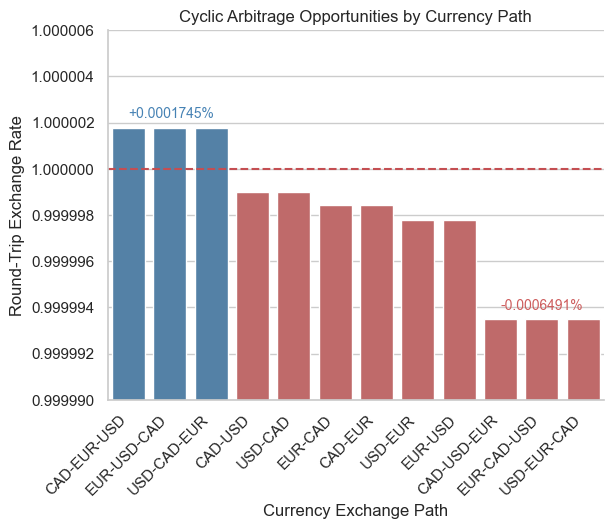

In [18]:
labels = er_df["path"]
sorted_er_df = er_df.sort_values("total_rate", ascending = False)

custom_params = {"axes.spines.right": False, "axes.spines.top": False} 
sns.set_theme(style="whitegrid", rc = custom_params)
colors = ["steelblue" if v > 1 else "indianred" for v in sorted_er_df["total_rate"]]
h = sns.barplot(
    data=sorted_er_df,
    x="path",
    y="total_rate",
    hue="path",
    palette=colors,
    legend=False,
)
h.set_ylim(0.99999, 1.000006)

plt.xticks(labels, labels, rotation=45, ha="right")
plt.axhline(1, c = 'r', linestyle = '--')

plt.annotate("+0.0001745%", ["CAD-EUR-USD", 1.0000022], fontsize=10, c="steelblue")
plt.annotate("-0.0006491%", ["CAD-USD-EUR", 0.9999939], fontsize=10, c="#CD5C5C")

plt.xlabel("Currency Exchange Path")
plt.ylabel("Round-Trip Exchange Rate")

plt.title("Cyclic Arbitrage Opportunities by Currency Path")
plt.gca().yaxis.set_major_formatter(plt.FormatStrFormatter("%.6f"))
plt.show()

### Findings on Exchange Rate Integrity

Triangular arbitrage opportunities are present in the current rate data. The deviations are small but non-trivial: round-trip factors are +0.000174% or -0.0001% to -0.0006% from 1.

**Example Impact**: On a $1,000,000 three-leg conversion, this implies a user could gain $1.74.

**Root Cause**: Five-decimal precision, while common in some FX contexts, is not enough for arbitrage-resistant rate consistency under this methodology.

### Recommendations

**Critical**: Mitigate by implementing one or more of:
1. Higher stored precision (7-8 decimal places)
2. Real-time rate refresh from authoritative external sources
3. Spreads wider than observed arbitrage windows

Without mitigation, users can exploit rate inconsistencies and create avoidable financial and operational risk.

## Conclusion and Recommendations

This analysis identifies where the platform is strong and where controls need to improve.

### Key Findings Summary
- **User Engagement**: wealth is concentrated among a subset of users, with broader participation underneath
- **Geographic Distribution**: average balances vary materially by country, suggesting region-specific product opportunities
- **Network Activity**: test data shows full user-to-user connectivity, likely denser than production behavior
- **Risk Management**: exchange-rate precision is the most urgent operational gap

### Next Steps
1. **Immediate**: increase exchange-rate precision and improve update logic
2. **Short-term**: expand geographic segmentation and region-level strategy analysis
3. **Ongoing**: monitor network structure and arbitrage indicators in near real time